<a href="https://colab.research.google.com/github/GustavoFA/IA368/blob/main/notebooks/LoRA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IA368-HH

## Modelo de Linguagem com auto-atenção e máscaras causais + LoRA

Gustavo Freitas Alves

236249

---


Neste notebook faço a implementação de um modelo DecoderOnly (pré-treino), e em seguida, faço um ajuste fino no modelo pré-treinado utilizando LoRA.

Alguns pontos que ressalto são:

* Divido meus dados na proporção sugerida: 70% - pré-treino | 20% - ajuste fino | 10% - validação. Como dataset uso os textos do Machado de Assis.

* Fiz janela deslizante em todas as sentenças, pois notei pouca presença, no geral, do token UNK. Ou seja, não descartei sentenças.

* Na classe do dataset ao produzir os targets substituo os tokens PAD e UNK por -100. E no critério indico esse valor para ser ignorado.

* Com relação ao LoRA, aplico em todas as camadas lineares (atenção e feed forward), utilizo rank de 4 e constante alpha igual a 1.

Por fim, foi possível observar uma melhora do modelo no ajuste fino, porém, o valor não foi muito significativo (aproximadamente, -7 de PPL). Ao meu ver, isso se deve ao fato de não haver diferença entre a tarefa de pré-treino e de ajuste fino, ou seja, estou treinando o modelo com menos parâmetros para a mesma tarefa. Seria interessante, treinar o modelo pré-treinado em alguma tarefa diferente (ou dataset diferente).


---

In [ ]:
import os

import copy

import re

import time

import time
import math

from collections import Counter

import random

import numpy as np

import pandas as pd

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

from matplotlib import pyplot as plt

Definindo dispositivo

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

---
## Dados

Clonando repositório com o texto a ser utilizado. Obras de Machado de Assis.

In [ ]:
# caminho para o arquivo
DATA_PATH_PT = r'projetomachado/textonormalizado1000.txt'

In [ ]:
!git clone -q https://github.com/ethelbeluzzi/projetomachado

#### Analisando os dados do texto

In [ ]:
characters = None
lines = None

# obtendo as linhas do texto
with open(DATA_PATH_PT, 'r') as text:
  lines = text.readlines()

Analisando uma parte do texto

In [ ]:
' '.join(lines[0:40])

'1\n MINISTÉRIO DA CULTURA\n Fundação Biblioteca Nacional\n Departamento Nacional do Livro\n A MÃO E A LUVA\n Machado de Assis\n I\n O fim da carta\n Mas que pretendes fazer agora?\n Morrer.\n Morrer? Que idéia! Deixate disso, Estêvão. Não se morre por tão pouco...\n Morrese. Quem não padece estas dores não as pode avaliar. O golpe foi profundo, e o\n meu coração é pusilânime; por mais aborrecível que pareça a idéia da morte, pior, muito pior do\n que ela, é a de viver. Ah! tu não sabes o que isto é?\n Sei: um namoro gorado...\n Luís!\n ... E se em cada caso de namoro gorado morresse um homem, tinha já diminuído muito o\n gênero humano, e Malthus perderia o latim. Anda, sobe.\n Estêvão meteu a mão nos cabelos com um gesto de angústia; Luís Alves sacudiu a cabeça\n e sorriu. Achavamse os dois no corredor da casa de Luís Alves, à rua da Constituição,  que\n então se chamava dos Ciganos;  então, isto é, em 1853, uma bagatela de vinte anos que lá vão,\n levando talvez consigo as ilusões do

In [ ]:
if lines:
  n = random.randint(0,len(lines))
  print(f'[{n}] - {lines[n]}')

[110591] - vez que me foi dado apreciar cara a cara, o famoso protagonista. Não sei que autor francês ou brasileiro?não me lembra teve a boa inspiração de cortar um drama do romance do Ponson du Terrail, idéia que o



Filtragem do texto

In [ ]:
# limpeza dos dados - remover \n e espaços
# Logo, estaremos mantendo palavras (incluindo acentos), pontuações, números e símbolos
# Irei manter diferenças de Maiúsculas e Minúsculas
# \w+ = caracteres alfanuméricos e underscore (uma ou mais)
# ^\w\s = pontuações e símbolos
# UNICODE -> permite letras com acentuações (além de letras gregas e dentre outras)
filter_lines = [" ".join(re.findall(r'\w+|[^\w\s]', line, flags=re.UNICODE)) for line in lines]

In [ ]:
print(f'[{n}] - {filter_lines[n]}')

[110591] - vez que me foi dado apreciar cara a cara , o famoso protagonista . Não sei que autor francês ou brasileiro ? não me lembra teve a boa inspiração de cortar um drama do romance do Ponson du Terrail , idéia que o


#### Separação dos dados


Separação do dataset para pré-treino (70%), ajuste fino (20%). O restante dos dados (10%) estaremos utilizando para validação.

Os dados serão divididos em:

lines_pre_training (70%)

lines_fine_tuning (20%)

lines_val (10%)

In [ ]:
%%time

# dataset para modelo de pré-treinamento e modelo de fine-tuning
# 80% dos dados para modelo pré-treinamento
# 20% dos dados para modelo ajuste fino
lines_pre_training, lines_fine_tuning = train_test_split(
    filter_lines,
    test_size=0.2,
    random_state=18,
)
# dos 80% dos dados que estão para o modelo pré-treino 12.5% serão utilizados
# para validação
lines_pre_training, lines_val = train_test_split(
    lines_pre_training,
    test_size=0.125,
    random_state=18,
)

CPU times: user 136 ms, sys: 3.87 ms, total: 140 ms
Wall time: 140 ms


Verificando distribuição dos dados

In [ ]:
print(f'Número de linhas para pré-treino: {len(lines_pre_training)} = {100*len(lines_pre_training)/len(filter_lines):.2f}% dos dados totais')
print(f'Número de linhas para ajuste fino: {len(lines_fine_tuning)} = {100*len(lines_fine_tuning)/len(filter_lines):.2f}% dos dados totais')
print(f'Número de linhas de validação: {len(lines_val)} = {100*len(lines_val)/len(filter_lines):.2f}% dos dados totais')

Número de linhas para pré-treino: 214486 = 70.00% dos dados totais
Número de linhas para ajuste fino: 61282 = 20.00% dos dados totais
Número de linhas de validação: 30641 = 10.00% dos dados totais


Verificando uma das linhas

In [ ]:
lines_pre_training[0]

'mestres retratados o fizeram sangrar de remorsos . Vexado e enfastiado , Pestana arremeteu contra aquela'

#### Vocabulário

Contagem de palavras do conjunto de treino

In [ ]:
def count_words(text):
  # classe para contagem das palavras
  word_counts = Counter()
  for words in text:
    # apenas obtenho as palavras para contagem
    # !! Lembrando que devemos passar para o Counter a lista de palavras e não uma string com todas as palavras
    word_counts.update(words.split())
  return word_counts

In [ ]:
words_rank = count_words(filter_lines)
words_rank.most_common(10)

[(',', 305962),
 ('.', 246961),
 ('a', 117877),
 ('que', 115658),
 ('de', 106619),
 ('e', 95157),
 ('o', 87822),
 (';', 53899),
 ('não', 48103),
 ('do', 39408)]

Criando o vocabulário com base em todas os tokens do texto original

In [ ]:
# Considerando apenas os tokens mais comuns do dataset completo
VOCAB_SIZE = 20000

In [ ]:
# Tokens especiais para nossa rede
special_tokens = ['<SOS>', '<EOS>', '<UNK>', '<PAD>']

In [ ]:
words_frequency = [word for word, count in words_rank.most_common(VOCAB_SIZE)]
# Acrescento os tokens especiais
words_frequency = special_tokens + words_frequency
vocab = {word: idx for idx, word in enumerate(words_frequency)}

In [ ]:
# tokens especiais
words_frequency[:4]

['<SOS>', '<EOS>', '<UNK>', '<PAD>']

In [ ]:
unk_value = vocab['<UNK>']
unk_value

2

#### Encoder/Decoder

Implemento codificador e decodificador

Codificador

In [ ]:
def encoder(_sentence, _vocab=vocab):
  # codifico as palavras seguindo o vocabulário e seguindo a filtragem aplicada anteriormente
  return [_vocab.get(word, unk_value) for word in _sentence.split()]

Decodificador

In [ ]:
reverse_vocab = {idx: word for word, idx in vocab.items()}
def decoder(_sentence, _reverse_vocab=reverse_vocab):
  # decodifica as palavras
  return ' '.join([_reverse_vocab.get(idx, '<UNK>') for idx in _sentence])

Verificando o codificador

In [ ]:
tokens_cod = encoder('Eu amo carros .')
tokens_cod

[143, 1227, 3525, 5]

Verificando o decodificador

In [ ]:
decoder(tokens_cod)

'Eu amo carros .'

In [ ]:
all_sentences_cod = [encoder(lines) for lines in filter_lines]

#### Checagem dos UNK

In [ ]:
print(f'Número médio de tokens por sentença: {sum([len(l) for l in all_sentences_cod])/len(all_sentences_cod):.2f} tokens')
n_tokens = [len(l) for l in all_sentences_cod]
print(f'Número total de tokens: {sum(n_tokens)}')
unk_tokens = [l.count(unk_value) for l in all_sentences_cod]
print(f'Número de tokens UNK: {sum(unk_tokens)} ==> {100*sum(unk_tokens)/sum(n_tokens):.2f} %')
print(f'Número médio de UNK por sentença: {sum(unk_tokens)/len(unk_tokens):.2f} token')

Número médio de tokens por sentença: 12.90 tokens
Número total de tokens: 3952039
Número de tokens UNK: 180854 ==> 4.58 %
Número médio de UNK por sentença: 0.59 token


---
## Dataset

Tamanho do contexto (mantive o mesmo tamanho do exercício anterior)

In [ ]:
CONTEXT_SIZE = 12

Dataset

Na minha classe Dataset não descarto as sentenças com UNK e utilizo janela deslizante com passos do tamanho do contexto.

In [ ]:
class MyDataset(Dataset):
  def __init__(self, sentences, n_pairs:int=None, ignore_index:list=None, context_size:int=CONTEXT_SIZE, special_tokens=special_tokens, vocab=vocab):
    # lista com códigos dos tokens especiais
    self.special_tokens = [i for i in range(len(special_tokens))]
    # indices a serem ignorados
    self.ignore_index = ignore_index

    self.context_size = context_size
    self.sentences = sentences
    self.vocab = vocab

    self.inputs = []
    self.targets = []

    # Iteração -> Janela deslizante com passos do tamanho do contexto
    for i, sentence in enumerate(self.sentences):
      sentence = self.encoder(sentence)
      for k, token in enumerate(sentence):
        # passos considerando o contexto
        step = k * self.context_size
        # armazeno as sentenças de input e target (já ajustando o número de tokens)
        # salvo inputs e targets (Mantenho os UNK)
        self.inputs.append(self.adjust_sentence(sentence[step:self.context_size+step]))
        # Passo os tokens a serem ignorados para -100
        self.targets.append(self.adjust_sentence(sentence[step+1:self.context_size+step+1], self.ignore_index))

        # Caso o último conjunto de target adicionado possua EOS, logo, devemos
        # parar de varrer a sentença
        if self.special_tokens[1] in self.targets[-1]:
          break
        if n_pairs is not None:
          if len(self.inputs) >= n_pairs:
            break
      if n_pairs is not None:
          if len(self.inputs) >= n_pairs:
            break

  def adjust_sentence(self, _sentence, ignore_index=None) -> list:
    # Caso a sentença possua um número de elementos menor que o contexto faremos
    # a adição de elementos PAD.
    if len(_sentence) < self.context_size:
      _sentence += [self.special_tokens[3]] * (self.context_size - len(_sentence))
    # condição para substituir UNK por PAD -> útil para o target
    if ignore_index:
      _sentence = [token if token not in ignore_index else -100 for token in _sentence]
    return _sentence

  def encoder(self, _sentence:list) -> list:
    # encoder da própria classe, que faz a codificação e adiciona tokens SOS e EOS.
    return [self.special_tokens[0]] + [self.vocab.get(word, self.special_tokens[2]) for word in _sentence.split()] + [self.special_tokens[1]]

  def __len__(self):
    return len(self.inputs)

  def __getitem__(self, idx):
    return torch.tensor(self.inputs[idx]), torch.tensor(self.targets[idx])

Criação dos datasets

Como estou utilizando o valor de -100 para os tokens especiais PAD [3] e UNK [2], logo, este valor será visto nos dados a seguir.

In [ ]:
%%time
# Caso esteja na cpu irei trabalhar com um dataset menor (útil para checagem geral)
if device.type == 'cpu':
  # Número de amostras para treino e validação (caso seja None será utilizado todos os dados)
  n_samples_train = 1000
  n_samples_val = 250
  # Dataset para pré-treino
  train_dataset_pre_training = MyDataset(lines_pre_training, n_samples_train, [2,3])
  # Dataset para ajuste fino
  train_dataset_fine_tuning = MyDataset(lines_fine_tuning, n_samples_train, [2,3])
  # Dataset de validação (estarei utilizando em ambos os modelos seguintes)
  val_dataset = MyDataset(lines_val, n_samples_val, [2, 3])
# Caso tenha gpu (cuda) faço com o dataset completo
else:
  train_dataset_pre_training = MyDataset(lines_pre_training, ignore_index=[2,3])
  train_dataset_fine_tuning = MyDataset(lines_fine_tuning, ignore_index=[2,3])
  val_dataset = MyDataset(lines_val, ignore_index=[2, 3])

CPU times: user 3.42 s, sys: 97.3 ms, total: 3.52 s
Wall time: 3.53 s


#### Verificando o dataset

Ressalto aqui que durante a verificação veremos tokens UNK, mas isso ocorre pois, não temos o código -100 no vocabulário, ou seja, tais valores serão convertidos para UNK.

In [ ]:
print(f'Tamanhos:\n\tTreino modelo pré-treino: {len(train_dataset_pre_training)} sentenças\n\tTreino modelo ajuste fino: {len(train_dataset_fine_tuning)} sentenças\n\tValidação: {len(val_dataset)} sentenças')

Tamanhos:
	Treino modelo pré-treino: 351370 sentenças
	Treino modelo ajuste fino: 100807 sentenças
	Validação: 50166 sentenças


In [ ]:
# contando o número de tokens UNK presentes na entrada do dataset de pré-treino
total = 0
unk_n = 0
for inp, _ in train_dataset_pre_training:
  total += inp.numel()
  unk_n += (inp == 2).sum().item()

print(f'Tokens totais: {total}')
print(f'Tokens UNK: {unk_n}')
print(f'Média de tokens por sentença: {100*unk_n/total:.2f} %')

Tokens totais: 4216440
Tokens UNK: 126679
Média de tokens por sentença: 3.00 %


In [ ]:
total = 0
unk_n = 0
# agora para o dataset de ajuste fino
for inp, _ in train_dataset_fine_tuning:
  total += inp.numel()
  unk_n += (inp == 2).sum().item()

print(f'Tokens totais: {total}')
print(f'Tokens UNK: {unk_n}')
print(f'Média de tokens por sentença: {100*unk_n/total:.2f} %')

Tokens totais: 1209684
Tokens UNK: 36112
Média de tokens por sentença: 2.99 %


Exemplo de um par (input, output)

In [ ]:
# Pré-treino
m = random.randint(0, len(train_dataset_pre_training))
for n, t in enumerate(train_dataset_pre_training):
  if n == m:
    print(f'Elemento {n} do Dataset para pré-treino')
    input, target = t
    print(20*'=')
    print(f'INPUT[{input.shape}]: {input}')
    print(f'INPUT + DECODE : {decoder(input.tolist())}')
    print('\n' + 20*'-'+'\n')
    print(f'TARGET[{target.shape}]: {target}')
    print(f'TARGET + DECODE : {decoder(target.tolist())}')
    print(20*'=')
    break

Elemento 118620 do Dataset para pré-treino
INPUT[torch.Size([12])]: tensor([    0,   107,    20,  1910,  3290,    42, 10766,     4,     9,     4,
           28,    66])
INPUT + DECODE : <SOS> isso se mostrou meiga ou compassiva , e , à minha

--------------------

TARGET[torch.Size([12])]: tensor([  107,    20,  1910,  3290,    42, 10766,     4,     9,     4,    28,
           66,  1961])
TARGET + DECODE : isso se mostrou meiga ou compassiva , e , à minha saída


In [ ]:
# Ajuste fino
m = random.randint(0, len(train_dataset_fine_tuning))
for n, t in enumerate(train_dataset_fine_tuning):
  if n == m:
    print(f'Elemento {n} do Dataset para ajuste fino')
    input, target = t
    print(20*'=')
    print(f'INPUT[{input.shape}]: {input}')
    print(f'INPUT + DECODE : {decoder(input.tolist())}')
    print('\n' + 20*'-'+'\n')
    print(f'TARGET[{target.shape}]: {target}')
    print(f'TARGET + DECODE : {decoder(target.tolist())}')
    print(20*'=')
    break

Elemento 34598 do Dataset para ajuste fino
INPUT[torch.Size([12])]: tensor([ 10, 129,   1,   3,   3,   3,   3,   3,   3,   3,   3,   3])
INPUT + DECODE : o melhor <EOS> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD>

--------------------

TARGET[torch.Size([12])]: tensor([ 129,    1, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100])
TARGET + DECODE : melhor <EOS> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK>


Verificando pares próximos - interessante para observar deslocamento dos tokens nas sentenças

In [ ]:
m = random.randint(0, len(train_dataset_pre_training))
for n, t in enumerate(train_dataset_pre_training):
  if n > m and n < m + 4:
    print(f'Elemento {n} do Dataset para pré-treino')
    input, target = t
    print(20*'=')
    print(f'INPUT[{input.shape}]: {input}')
    print(f'INPUT + DECODE : {decoder(input.tolist())}')
    print(20*'-')
    print(f'TARGET[{target.shape}]: {target}')
    print(f'TARGET + DECODE : {decoder(target.tolist())}')
    print(20*'=')
    print('\n')

Elemento 239913 do Dataset para pré-treino
INPUT[torch.Size([12])]: tensor([   0,   41, 4881, 1042,   10,   31,    2, 1071,   11,    1,    3,    3])
INPUT + DECODE : <SOS> O copo cheio o mais <UNK> canto ; <EOS> <PAD> <PAD>
--------------------
TARGET[torch.Size([12])]: tensor([  41, 4881, 1042,   10,   31, -100, 1071,   11,    1, -100, -100, -100])
TARGET + DECODE : O copo cheio o mais <UNK> canto ; <EOS> <UNK> <UNK> <UNK>


Elemento 239914 do Dataset para pré-treino
INPUT[torch.Size([12])]: tensor([   0,  374,    5,  533,  665,    4,   27,   45,   14, 1730,    8,    2])
INPUT + DECODE : <SOS> deles . Ela sorriu , mas foi um sorrir de <UNK>
--------------------
TARGET[torch.Size([12])]: tensor([ 374,    5,  533,  665,    4,   27,   45,   14, 1730,    8, -100,    5])
TARGET + DECODE : deles . Ela sorriu , mas foi um sorrir de <UNK> .


Elemento 239915 do Dataset para pré-treino
INPUT[torch.Size([12])]: tensor([5, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3])
INPUT + DECODE : . <EOS> <PAD> <PAD> <P

---
## DataLoader

In [ ]:
# Seleção do batch size baseado no dispositivo disponível
if device.type == "cuda":
  batch_size = 1024
else:
  batch_size = 64
print(f'Batch Size: {batch_size}')

Batch Size: 1024


In [ ]:
train_loader_pre_training = DataLoader(train_dataset_pre_training, batch_size=batch_size, shuffle=True)
train_loader_fine_tuning = DataLoader(train_dataset_fine_tuning, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

#### Verificando DataLoader

In [ ]:
m = random.randint(0, len(train_loader_pre_training))
for n, t in enumerate(train_loader_pre_training):
  if n == m:
    print(f'Batch {n} - Dimensão : [{t[0].shape}, {t[1].shape}]')
    input, target = t
    print(20*'=')
    print(f'INPUT:\t{input}')
    print(20*'-')
    print(f'TARGET:\t{target}')
    print(20*'=')
    break

Batch 68 - Dimensão : [torch.Size([1024, 12]), torch.Size([1024, 12])]
INPUT:	tensor([[    0,   144,   206,  ...,     4,     1,     3],
        [    0,    35, 10693,  ...,   374,    23,   167],
        [  482,     4,   109,  ...,  1197,     1,     3],
        ...,
        [    0,     8,   836,  ...,     3,     3,     3],
        [   37,    12,     1,  ...,     3,     3,     3],
        [    0,  1032,     4,  ...,     7,  1974,   116]])
--------------------
TARGET:	tensor([[  144,   206, 16744,  ...,     1,  -100,  -100],
        [   35, 10693,     5,  ...,    23,   167,   998],
        [    4,   109,    10,  ...,     1,  -100,  -100],
        ...,
        [    8,   836,     5,  ...,  -100,  -100,  -100],
        [   12,     1,  -100,  ...,  -100,  -100,  -100],
        [ 1032,     4,  2689,  ...,  1974,   116,     8]])


In [ ]:
for n, t in enumerate(train_loader_fine_tuning):
  x, y = t
  print(f'Batch {n} - Dimensão : INPUT-{x.shape} | TARGET-{y.shape}]')
  if n > 5:
    break

Batch 0 - Dimensão : INPUT-torch.Size([1024, 12]) | TARGET-torch.Size([1024, 12])]
Batch 1 - Dimensão : INPUT-torch.Size([1024, 12]) | TARGET-torch.Size([1024, 12])]
Batch 2 - Dimensão : INPUT-torch.Size([1024, 12]) | TARGET-torch.Size([1024, 12])]
Batch 3 - Dimensão : INPUT-torch.Size([1024, 12]) | TARGET-torch.Size([1024, 12])]
Batch 4 - Dimensão : INPUT-torch.Size([1024, 12]) | TARGET-torch.Size([1024, 12])]
Batch 5 - Dimensão : INPUT-torch.Size([1024, 12]) | TARGET-torch.Size([1024, 12])]
Batch 6 - Dimensão : INPUT-torch.Size([1024, 12]) | TARGET-torch.Size([1024, 12])]


---
## Modelo

Dimensões:

* B - Dimensão do Batch
* S - Dimensão da sequência (contexto)
* E - Dimensão do Embedding
* d - Dimensão do Head
* H - Número de Heads
* V - Dimensão do Vocabulário

#### LoRA

$$y = W_0x + \Delta W x  = W_0x + BAx \times \frac{\alpha}{r}$$

$W_0$ : Matriz de pesos do pré-treinamento ($\mathbb{R}^{output \times input}$)

$\alpha$ : fator de escala

$r$ : rank ($r \ll min(input, output)$)

$A$ : Matriz treinável ($\mathbb{R}^{r \times input}$)

$B$ : Matriz treinável ($\mathbb{R}^{output \times r}$)








Definindo hiperparâmetros da LoRA

In [ ]:
RANK = 4
ALPHA = 1.0

#### Low-Rank Adaptation

Apliquei LoRA em todas as camadas lineares, ou seja, nas projeções de atenção, na MLP e na camada de saída.


In [ ]:
class LoRA(nn.Module):
  def __init__(self, input_size, output_size, bias:bool=False, rank:int=RANK, alpha:float=ALPHA):
    super(LoRA, self).__init__()
    self.rank = rank # rank para decoposição
    self.alpha = alpha # fator de escala
    self.scaling = alpha/rank

    # Parte congelada (para os pesos)
    # Peso original
    self.weight = nn.Parameter(torch.zeros(output_size, input_size))
    # Não atualiza os pesos
    self.weight.requires_grad = False

    # Parte congelada (para os bias)
    # Bias original
    if bias:
      self.bias = nn.Parameter(torch.zeros(output_size))
      self.bias.requires_grad = False
    else:
      self.register_parameter('bias', None)

    # Adaptação
    # matrizes A e B
    self.A = nn.Linear(input_size, rank, bias=False)
    self.B = nn.Linear(rank, output_size, bias=False)
    # Inicialização das matrizes A e B
    # A = Gaussiana (4.1 - Low-Rank-Paramtrized update matrices)
    nn.init.normal_(self.A.weight, mean=0.0, std=0.02)
    # B = Zeros
    nn.init.zeros_(self.B.weight)

  # Método para criar o LoRA a partir de uma camada Linear
  @classmethod
  def from_linear(cls, linear:nn.Linear, bias:bool=False, rank:int=RANK, alpha:float=ALPHA):
    # instancio o LoRA
    lora = cls(linear.in_features, linear.out_features, linear.bias is not None, rank, alpha)
    # Clonagem dos pesos
    lora.weight.data = linear.weight.data.clone()
    if linear.bias is not None:
      # clonagem dos bias
      lora.bias.data = linear.bias.data.clone()
    return lora

  def forward(self, x):
    base = F.linear(x, self.weight, self.bias)
    lora = self.B(self.A(x)) * self.scaling # DeltaW * alpha/rank
    return base + lora

#### Máscara de atenção

In [ ]:
class MaskedMultiHeadAttention(nn.Module):
    """
      Masked Multi-Head Attention
    """
    def __init__(self, embed_size, num_heads=4, dropout=0.1, lora=True, check_mask=False):
        super(MaskedMultiHeadAttention, self).__init__()
        # Flag para acionar o modo de checagem da máscara de atenção
        # Apenas para debug
        self.check_mask = check_mask

        self.num_heads = num_heads
        self.head_dim = embed_size // num_heads

        # Projeções de Q, K, V (Sem LoRA)
        if not lora:
          self.qkv = nn.Linear(embed_size, 3 * embed_size, bias=False)
          self.proj_out = nn.Linear(embed_size, embed_size, bias=False)
        # Quando aplicar LoRA as projeções serão construídas com base nas matrizes A e B
        else:
          self. qkv = LoRA.from_linear(nn.Linear(embed_size, 3 * embed_size, bias=False))
          self.proj_out = LoRA.from_linear(nn.Linear(embed_size, embed_size, bias=False))

        # Dropouts
        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)

        # Máscara causal pré-computada (salvar no buffer, pois não será aprendida)
        mask = torch.tril(torch.ones(CONTEXT_SIZE, CONTEXT_SIZE))
        self.register_buffer("mask", mask)

    def forward(self, x):
        B, S, E = x.shape  # [batch, seq_len, embed_size]

        # Projeta Q, K, V
        qkv = self.qkv(x)  # [B, S, 3*E]
        Q, K, V = qkv.chunk(3, dim=-1)  # [B, S, E]

        # Múltiplas heads
        Q = Q.view(B, S, self.num_heads, self.head_dim).transpose(1, 2)  # [B, H, S, d]
        K = K.view(B, S, self.num_heads, self.head_dim).transpose(1, 2)  # [B, H, S, d]
        V = V.view(B, S, self.num_heads, self.head_dim).transpose(1, 2)  # [B, H, S, d]

        # Scores de atenção
        scores = (Q @ K.transpose(-2, -1)) / (self.head_dim ** 0.5)  # [B, H, S, S]

        # Aplica máscara causal (ajusta para o tamanho da sequência)
        scores = scores.masked_fill(self.mask == 0, float('-inf'))
        if self.check_mask:
          print(scores)

        # Softmax (+ dropout)
        attn_weights = F.softmax(scores, dim=-1)  # [B, H, S, S]
        attn_weights = self.attn_dropout(attn_weights)

        out = attn_weights @ V  # [B, H, S, d]

        out = out.transpose(1, 2).contiguous().view(B, S, E) # [B, S, E]

        # Projeção final + dropout
        out = self.proj_out(out)
        out = self.resid_dropout(out)

        return out


#### MLP

In [ ]:
class MLP(nn.Module):
  """
    Feed Forward Neural Network - Embeddings -> Logits
  """
  def __init__(self, embed_dim, hidden_dim, lora:bool=True):
    super(MLP, self).__init__()

    # Aplicação da LoRA
    if lora:
        self.fc1 = LoRA.from_linear(nn.Linear(embed_dim, hidden_dim), True)
        self.fc2 = LoRA.from_linear(nn.Linear(hidden_dim, embed_dim), True)
    else:
        self.fc1 = nn.Linear(embed_dim, hidden_dim) # [B, H]
        self.fc2 = nn.Linear(hidden_dim, embed_dim) # [B, H]

  def forward(self, x):
    # GELU + Linear (vocab)
    return self.fc2(F.gelu(self.fc1(x)))

#### Decoder Transformer

In [ ]:
class DecoderTransformer(nn.Module):
  """
    Classe do Decoder Transformer (junção de MaskedMultiHead + MLP)
  """
  def __init__(self, vocab_size, embed_size, context_size, num_heads:int=4, num_layers:int=4, lora:bool=True):
      super(DecoderTransformer, self).__init__()

      # emb token
      self.token_embedding = nn.Embedding(vocab_size, embed_size)
      # emb posicional
      self.position_embedding = nn.Embedding(context_size, embed_size)

      # blocos
      self.layers = nn.ModuleList([
          nn.ModuleList([
              nn.LayerNorm(embed_size),
              # Aqui sendo aplicado LoRA
              MaskedMultiHeadAttention(embed_size, num_heads, lora=lora),
              nn.LayerNorm(embed_size),
              # Aqui também está sendo aplicado LoRA
              MLP(embed_size, embed_size * 4, lora)
          ]) for _ in range(num_layers)
      ])

      self.norm = nn.LayerNorm(embed_size)

      # projeção final para logits
      # Aplico LoRA
      if lora:
        self.output = LoRA.from_linear(nn.Linear(embed_size, vocab_size), True)
      else:
        self.output = nn.Linear(embed_size, vocab_size)

      self.dropout = nn.Dropout(0.1)

  def forward(self, x):
      B, T = x.shape # [B, S]

      # embeddings
      token_emb = self.token_embedding(x)                # [B, S, E]
      pos_emb = self.position_embedding(torch.arange(T, device=x.device))  # [S, E]
      x = token_emb + pos_emb                            # [B, S, E]
      x = self.dropout(x)

      # camadas do decoder
      for ln1, attn, ln2, mlp in self.layers:
          # masked self attention
          x_res = x
          x = attn(ln1(x)) + x_res     # norm + residual + atenção - [B, S, E]
          # feed forward
          x_res = x
          x = mlp(ln2(x)) + x_res      # norm + residual + mlp - [B, S, E]

      # normalização final
      x = self.norm(x)      # [B, S, E]

      # projeção para logits
      logits = self.output(x)          # (B, S, V)
      return logits

### Modelo Pre-Training

Criação do modelo com embedding size de 256 (apenas mantive o mesmo embedding size do exercício anterior)

In [ ]:
# modelo para pré-treino
# LoRA falso
model_pre_training = DecoderTransformer(len(vocab), 256, CONTEXT_SIZE, lora=False).to(device)

In [ ]:
model_pre_training

DecoderTransformer(
  (token_embedding): Embedding(20004, 256)
  (position_embedding): Embedding(12, 256)
  (layers): ModuleList(
    (0-3): 4 x ModuleList(
      (0): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (1): MaskedMultiHeadAttention(
        (qkv): Linear(in_features=256, out_features=768, bias=False)
        (proj_out): Linear(in_features=256, out_features=256, bias=False)
        (attn_dropout): Dropout(p=0.1, inplace=False)
        (resid_dropout): Dropout(p=0.1, inplace=False)
      )
      (2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (3): MLP(
        (fc1): Linear(in_features=256, out_features=1024, bias=True)
        (fc2): Linear(in_features=1024, out_features=256, bias=True)
      )
    )
  )
  (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (output): Linear(in_features=256, out_features=20004, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)

#### Verificando o funcionamento da máscara causal

In [ ]:
x = torch.randn(1, CONTEXT_SIZE, 16)

In [ ]:
att = MaskedMultiHeadAttention(16, 2, 0, check_mask=True)

Podemos notar abaixo que temos uma máscara causal correta

In [ ]:
att(x)

tensor([[[[-0.3130,    -inf,    -inf,    -inf,    -inf,    -inf,    -inf,
              -inf,    -inf,    -inf,    -inf,    -inf],
          [ 0.0739, -0.0669,    -inf,    -inf,    -inf,    -inf,    -inf,
              -inf,    -inf,    -inf,    -inf,    -inf],
          [ 0.2808, -0.0270,  0.2501,    -inf,    -inf,    -inf,    -inf,
              -inf,    -inf,    -inf,    -inf,    -inf],
          [ 0.1549, -0.3185, -0.2427, -0.2450,    -inf,    -inf,    -inf,
              -inf,    -inf,    -inf,    -inf,    -inf],
          [ 0.0636,  0.0720, -0.1109, -0.4992, -0.0834,    -inf,    -inf,
              -inf,    -inf,    -inf,    -inf,    -inf],
          [-0.2237,  0.3393, -0.2837, -0.6585,  0.1341, -0.3248,    -inf,
              -inf,    -inf,    -inf,    -inf,    -inf],
          [-0.1465,  0.0772,  0.0143, -0.0026, -0.2523,  0.1441,  0.0561,
              -inf,    -inf,    -inf,    -inf,    -inf],
          [ 0.1447, -0.1521,  0.2748, -0.0484, -0.1166, -0.2594,  0.2575,
         

tensor([[[ 3.7058e-01,  3.1003e-01,  2.5378e-01, -2.0953e-01, -1.4304e-01,
          -5.3823e-01,  1.9114e-01, -4.4996e-01,  4.7425e-02, -1.7074e-01,
           2.3668e-01,  3.1477e-01, -1.4162e-01,  4.3004e-01,  5.1112e-01,
          -6.1190e-01],
         [-7.5684e-02,  4.6885e-02, -2.4254e-01,  1.7156e-01, -1.1992e-01,
          -4.2223e-01,  4.8047e-03, -2.0569e-01, -1.4794e-01, -3.9366e-01,
           3.4621e-01,  2.0329e-01, -3.8158e-01, -4.8353e-02,  2.4924e-01,
          -2.2705e-01],
         [-1.8532e-02,  1.3075e-01, -6.0429e-02, -5.6129e-02, -1.6977e-01,
          -2.4850e-01, -3.1261e-02, -2.5734e-01,  1.0141e-01, -1.2944e-01,
           2.1766e-01,  2.1141e-01, -1.1031e-01,  1.7812e-01,  3.0804e-01,
           3.5949e-02],
         [-1.2701e-02,  1.0640e-01,  2.4760e-02, -2.2400e-02, -9.0148e-02,
          -2.5089e-01,  5.7650e-02, -2.4595e-01,  8.7197e-02, -2.0184e-01,
           2.2834e-01,  1.9298e-01, -1.3290e-01,  1.8250e-02,  3.1445e-01,
           3.7624e-02],
    

#### Verificando a inferência do modelo

In [ ]:
inputs, target = next(iter(train_loader_pre_training))
inputs, target = inputs.to(device), target.to(device)

In [ ]:
%%time
model_pre_training.train()
logits = model_pre_training(inputs)

CPU times: user 84.9 ms, sys: 89.9 ms, total: 175 ms
Wall time: 509 ms


In [ ]:
logits.shape, target.shape

(torch.Size([1024, 12, 20004]), torch.Size([1024, 12]))

In [ ]:
logits[0, :2, :]

tensor([[-0.2391, -0.0691,  0.5099,  ..., -0.4897, -0.7786,  0.5083],
        [ 0.2249, -0.6480, -0.3280,  ...,  0.0619, -0.0679, -0.8304]],
       device='cuda:0', grad_fn=<SliceBackward0>)

In [ ]:
probs = torch.softmax(logits, dim=-1)
pred_token = torch.argmax(probs, dim=-1)

In [ ]:
pred_token[0], target[0]

(tensor([10510,  5459,  6363,  9736,  1009, 12954, 15329,  7589,  7692, 19655,
          2861, 11513], device='cuda:0'),
 tensor([ 566,    4, 1896,  507,  101,    5,    5,    5, 1132,    4, 6705,   70],
        device='cuda:0'))

#### Verificando o número de parâmetros

In [ ]:
print(f"Parâmetros totais: {sum(p.numel() for p in model_pre_training.parameters()):,}\nParâmetros Treináveis: {sum(p.numel() for p in model_pre_training.parameters() if p.requires_grad):,}")

Parâmetros totais: 13,420,580
Parâmetros Treináveis: 13,420,580


Checando se há alguma camada congelada para o pré-treino

In [ ]:
def check_frozen_layers(model):
  return [name for name, param in model.named_parameters() if not param.requires_grad]

In [ ]:
print(f'Camadas congeladas:\n{check_frozen_layers(model_pre_training)}')

Camadas congeladas:
[]


---
## Hiperparâmetros

In [ ]:
EPOCHS = 20
lr = 5e-4
patience = 5

#### Otimizador

In [ ]:
optimizer = optim.AdamW(model_pre_training.parameters(), lr=lr)

#### Critério

Ignorar os tokens especiais PAD e UNK (isso foi definido quando instanciei os datasets, pois ambos estão codificados como -100)

In [ ]:
criterion = nn.CrossEntropyLoss(ignore_index=-100)

---
## Pré-Treino

### Treino e validação

Primeiro, vamos checar a perplexidade inicial

In [ ]:
%%time
model_pre_training.eval()
model_pre_training.to(device)

total_loss = 0
total_size = 0

with torch.no_grad():
  for context, target in val_loader:
    context, target = context.to(device), target.to(device)

    output = model_pre_training(context)
    # deve ajustar as dimensões
    loss = criterion(output.view(-1, output.size(-1)), target.view(-1))

    total_loss += loss.item() * context.size(0)
    total_size += context.size(0)

avg_loss = total_loss / total_size
perplexity = math.exp(avg_loss)


print(f'Perplexidade antes do treino: {perplexity:.2f}')

Perplexidade antes do treino: 23040.88
CPU times: user 4.14 s, sys: 17.7 ms, total: 4.15 s
Wall time: 4.21 s


Função de treion

In [ ]:
def train_loop(model, criterion, optimizer, train_loader, val_loader, epochs, device=device, patience=10, save_name:str='best_param'):

  # Variáveis para aplicação de early stoppping e salvar os parâmetros do melhor modelo (considerando a PPL na validação)
  patience_counter = 0
  best_ppl_val = 1e5 # valor maior do que a perplexidade inicial
  best_model_param = None

  model = model.to(device)

  # Para este exercício preferi já armazenar direto a ppl, inclusive para observar durante o treinamento
  ppl_train = []
  ppl_val = []

  for epoch in range(epochs):

    # obtenho tempo para cálculo de tempo por época
    start_time = time.time()

    # TREINO
    model.train()

    total_loss_train = 0
    total_size = 0

    for context, target in tqdm(train_loader, desc=f'[TRAIN] : Epoch {epoch+1}/{epochs}', leave=False):
      context, target = context.to(device), target.to(device)
      # Zero o gradiente para próximo cálculo (ou eles irão se acumular ao longo dos batches)
      optimizer.zero_grad()

      # output com os logits
      output = model(context)

      # NLL-Loss (cálculo de Loss) + LogSoftmax (probabilidades logarítmicas)
      # loss = criterion(output, target) # retorna média da perda por batch (reduction=mean)
      loss = criterion(output.view(-1, output.size(-1)), target.view(-1))

      # Propagação dos gradientes
      loss.backward()
      # atualizo os pesos do modelo
      optimizer.step()

      # cálculo da Loss para esse batch
      total_loss_train += loss.item() * context.size(0)
      total_size += context.size(0)

    # Cálculo da Loss de treino
    avg_loss_train = total_loss_train / total_size

    # VALIDAÇÃO
    model.eval()

    total_loss_val = 0
    total_size = 0

    # desativo cálculo de gradiente
      # menos uso da memória para armazenamento de variáveis intermediária
       # (grafos computacionais resultantes das operações com tensores)
      # execução mais rápida
    with torch.no_grad():
      for context, target in tqdm(val_loader, desc=f'[VAL] : Epoch {epoch+1}/{epochs}', leave=False):
        context, target = context.to(device), target.to(device)

        # logits
        output = model(context)
        # média do batch - prob log
        # loss = criterion(output, target)
        loss = criterion(output.view(-1, output.size(-1)), target.view(-1))

        # cálculo da Loss do batch
        total_loss_val += loss.item() * context.size(0)
        total_size += context.size(0)

    # loss val
    avg_loss_val = total_loss_val / total_size

    # cálculo final de tempo (treino + validação)
    epoch_time = time.time() - start_time

    # adiciono PPL de treino e validação
    ppl_train.append(math.exp(avg_loss_train))
    ppl_val.append(math.exp(avg_loss_val))

    print(f'Epoch: {epoch+1}/{epochs} | Time: {epoch_time:.2f}s | Train PPL: {ppl_train[-1]:.2f} | Val PPL: {ppl_val[-1]:.2f}')

    # Early stopping
    if int(ppl_val[-1]) < best_ppl_val:
      best_ppl_val = int(ppl_val[-1])
      patience_counter = 0
      best_model_param = model.state_dict()
    else:
      patience_counter += 1
      if patience_counter >= patience:
        print(f'\nEARLY STOPPING TRIGGERED')
        model.load_state_dict(best_model_param)
        break
  # salvo os melhores parâmetros nos arquivos (para poder salvar e só carregar depois)
  os.makedirs('content/model_parameters', exist_ok=True)
  torch.save(model.state_dict(), f'content/model_parameters/{save_name}.pt')

  return ppl_train, ppl_val

Treinamento

In [ ]:
%%time
train_ppl_1, val_ppl_1 = train_loop(model_pre_training, criterion, optimizer, train_loader_pre_training, val_loader, EPOCHS, device, patience, 'best_param_pre_training')

Epoch: 1/20 | Time: 88.79s | Train PPL: 356.81 | Val PPL: 204.17


Epoch: 2/20 | Time: 88.97s | Train PPL: 175.30 | Val PPL: 153.24


Epoch: 3/20 | Time: 88.22s | Train PPL: 138.94 | Val PPL: 131.16


Epoch: 4/20 | Time: 88.96s | Train PPL: 118.75 | Val PPL: 117.86


Epoch: 5/20 | Time: 89.06s | Train PPL: 104.60 | Val PPL: 108.77


...

Epoch: 16/20 | Time: 89.02s | Train PPL: 44.97 | Val PPL: 80.90


Epoch: 17/20 | Time: 88.63s | Train PPL: 42.84 | Val PPL: 80.06


Epoch: 18/20 | Time: 89.18s | Train PPL: 40.90 | Val PPL: 79.78


Epoch: 19/20 | Time: 88.66s | Train PPL: 39.18 | Val PPL: 79.17


Epoch: 20/20 | Time: 89.26s | Train PPL: 37.63 | Val PPL: 79.01
CPU times: user 29min 12s, sys: 26.4 s, total: 29min 38s
Wall time: 29min 37s


#### Resultado no Pré-treino

Verificando o comportamento da PERPLEXIDADE

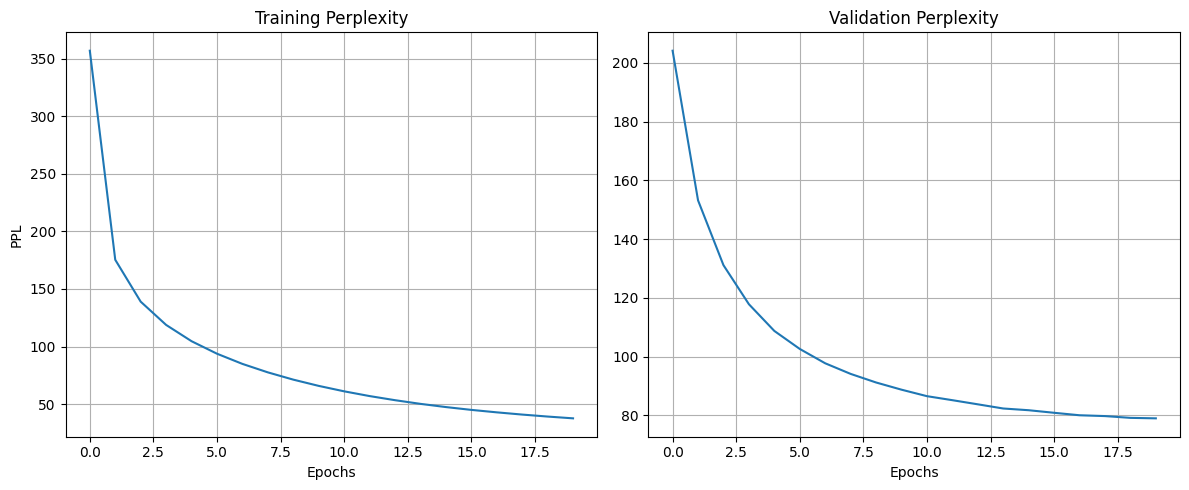

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(train_ppl_1)
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel('PPL')
axes[0].set_title(f"Training Perplexity")
axes[0].grid(True)

axes[1].plot(val_ppl_1)
axes[1].set_xlabel("Epochs")
axes[1].set_title("Validation Perplexity")
axes[1].grid(True)

plt.tight_layout()
plt.show()

Abaixo temos uma tabela com os valores

In [ ]:
pd.DataFrame({
    "EPOCH": list(range(1, len(train_ppl_1)+1)),
    "TRAIN_PPL": train_ppl_1,
    "VAL_PPL": val_ppl_1
})

,EPOCH,TRAIN_PPL,VAL_PPL
0,1,356.814245,204.173391
1,2,175.302443,153.236321
2,3,138.940706,131.155498
3,4,118.749006,117.864107
4,5,104.603412,108.768157
5,6,93.744083,102.637739
6,7,84.899445,97.752362
7,8,77.546935,94.142382
8,9,71.237604,91.216538
9,10,65.807302,88.766994


Menor perplexidade - Ressalto que o modelo de pré-treino terá os parâmetros desta época

In [ ]:
print(f'Perplexidade mínima: {min(val_ppl_1):.2f} - atingida na época {val_ppl_1.index(min(val_ppl_1))+1}')

Perplexidade mínima: 79.01 - atingida na época 20


---

## Fine-Tuning com LoRA

O modelo para fine tuning será criado com a LoRA e irei carregar os pesos do modelo do pré-treino

In [ ]:
# Instancio o modelo com LoRA
model_fine_tuning = DecoderTransformer(len(vocab), 256, CONTEXT_SIZE, lora=True).to(device)

Merge dos pesos

In [ ]:
pre_trained_dict = model_pre_training.state_dict()
fine_tuning_dict = model_fine_tuning.state_dict()

pre_trained_dict = {k: v for k, v in pre_trained_dict.items() if k in fine_tuning_dict and v.shape == fine_tuning_dict[k].shape}

fine_tuning_dict.update(pre_trained_dict)
model_fine_tuning.load_state_dict(fine_tuning_dict)

<All keys matched successfully>

In [ ]:
# learning rate para ajuste fino (utilizo passos maiores)
lr2 = 1e-3

In [ ]:
def fine_tuning(model, train_loader, val_loader, learning_rate, criterion, epochs, device=device, patience=2):

  # crio uma cópia do modelo (podendo assim verificar ambos os modelos)
  # _model = model.to(device)

  # congelar todos os parâmetros diferentes das matrizes A e B
  for name, param in model.named_parameters():
    if "A" in name or "B" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False


  # Otimizador para o LoRA
  optimizer = optim.AdamW(
                          filter(lambda p: p.requires_grad, model.parameters()),
                          lr=learning_rate
                          )

  return train_loop(model, criterion, optimizer, train_loader, val_loader, epochs, device, patience, 'best_param_fine_tuning')

Antes de fazer o fine tuning verifico quais camadas estão congeladas e quais são trienáveis

In [ ]:
print(f'Camadas congeladas:\n{check_frozen_layers(model_fine_tuning)}')

Camadas congeladas:
['layers.0.1.qkv.weight', 'layers.0.1.proj_out.weight', 'layers.0.3.fc1.weight', 'layers.0.3.fc1.bias', 'layers.0.3.fc2.weight', 'layers.0.3.fc2.bias', 'layers.1.1.qkv.weight', 'layers.1.1.proj_out.weight', 'layers.1.3.fc1.weight', 'layers.1.3.fc1.bias', 'layers.1.3.fc2.weight', 'layers.1.3.fc2.bias', 'layers.2.1.qkv.weight', 'layers.2.1.proj_out.weight', 'layers.2.3.fc1.weight', 'layers.2.3.fc1.bias', 'layers.2.3.fc2.weight', 'layers.2.3.fc2.bias', 'layers.3.1.qkv.weight', 'layers.3.1.proj_out.weight', 'layers.3.3.fc1.weight', 'layers.3.3.fc1.bias', 'layers.3.3.fc2.weight', 'layers.3.3.fc2.bias', 'output.weight', 'output.bias']


Verificando todas as camadas

In [ ]:
layers_trainable = [name for name, param in model_fine_tuning.named_parameters() if param.requires_grad]
layers_frozen = [name for name, param in model_fine_tuning.named_parameters() if not param.requires_grad]
print(f'Camadas treináveis[{len(layers_trainable)}]: {layers_trainable}')
print(f'Camadas congeladas[{len(layers_frozen)}]: {layers_frozen}')

Camadas treináveis[54]: ['token_embedding.weight', 'position_embedding.weight', 'layers.0.0.weight', 'layers.0.0.bias', 'layers.0.1.qkv.A.weight', 'layers.0.1.qkv.B.weight', 'layers.0.1.proj_out.A.weight', 'layers.0.1.proj_out.B.weight', 'layers.0.2.weight', 'layers.0.2.bias', 'layers.0.3.fc1.A.weight', 'layers.0.3.fc1.B.weight', 'layers.0.3.fc2.A.weight', 'layers.0.3.fc2.B.weight', 'layers.1.0.weight', 'layers.1.0.bias', 'layers.1.1.qkv.A.weight', 'layers.1.1.qkv.B.weight', 'layers.1.1.proj_out.A.weight', 'layers.1.1.proj_out.B.weight', 'layers.1.2.weight', 'layers.1.2.bias', 'layers.1.3.fc1.A.weight', 'layers.1.3.fc1.B.weight', 'layers.1.3.fc2.A.weight', 'layers.1.3.fc2.B.weight', 'layers.2.0.weight', 'layers.2.0.bias', 'layers.2.1.qkv.A.weight', 'layers.2.1.qkv.B.weight', 'layers.2.1.proj_out.A.weight', 'layers.2.1.proj_out.B.weight', 'layers.2.2.weight', 'layers.2.2.bias', 'layers.2.3.fc1.A.weight', 'layers.2.3.fc1.B.weight', 'layers.2.3.fc2.A.weight', 'layers.2.3.fc2.B.weight', 'l

Treinamento (ajuste)

In [ ]:
train_ppl_2, val_ppl_2 = fine_tuning(model_fine_tuning, train_loader_fine_tuning, val_loader, lr2, criterion, EPOCHS, device, patience)

Epoch: 1/20 | Time: 31.86s | Train PPL: 87.45 | Val PPL: 74.92


Epoch: 2/20 | Time: 31.79s | Train PPL: 82.36 | Val PPL: 73.27


Epoch: 3/20 | Time: 32.11s | Train PPL: 80.10 | Val PPL: 72.86


Epoch: 4/20 | Time: 31.74s | Train PPL: 79.12 | Val PPL: 72.62


Epoch: 5/20 | Time: 31.89s | Train PPL: 78.25 | Val PPL: 72.48


Epoch: 6/20 | Time: 31.82s | Train PPL: 77.72 | Val PPL: 72.45


Epoch: 7/20 | Time: 31.76s | Train PPL: 77.09 | Val PPL: 72.41


Epoch: 8/20 | Time: 31.73s | Train PPL: 76.68 | Val PPL: 72.39

EARLY STOPPING TRIGGERED


Resultados para o modelo com fine-tuning

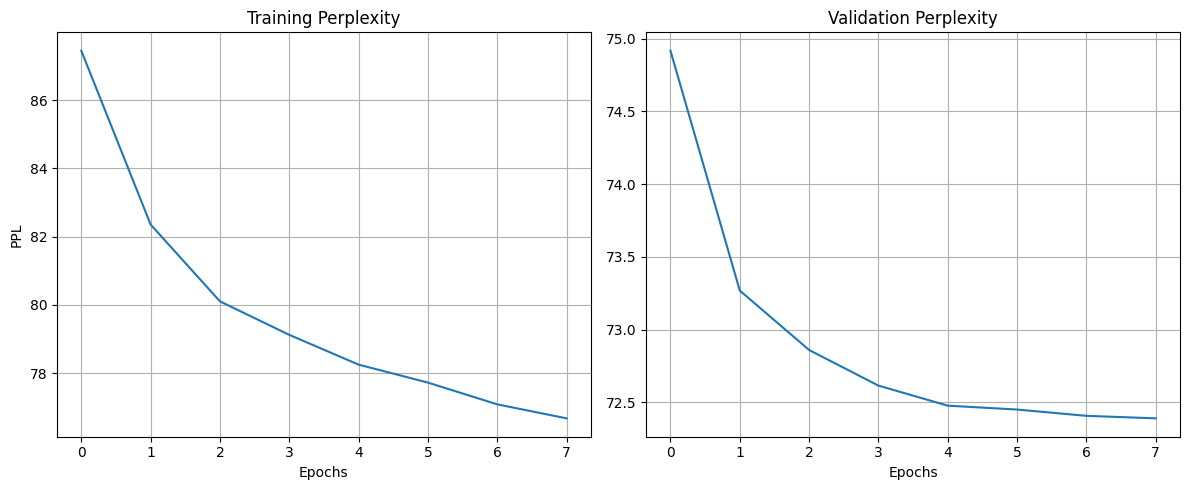

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(train_ppl_2)
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel('PPL')
axes[0].set_title(f"Training Perplexity")
axes[0].grid(True)

axes[1].plot(val_ppl_2)
axes[1].set_xlabel("Epochs")
axes[1].set_title("Validation Perplexity")
axes[1].grid(True)

plt.tight_layout()
plt.show()

Tabela com valores

In [ ]:
pd.DataFrame({
    "EPOCH": list(range(1, len(train_ppl_2)+1)),
    "TRAIN_PPL": train_ppl_2,
    "VAL_PPL": val_ppl_2
})

,EPOCH,TRAIN_PPL,VAL_PPL
0,1,87.449444,74.916986
1,2,82.355868,73.268440
2,3,80.104749,72.860021
3,4,79.122949,72.615195
4,5,78.250552,72.477294
5,6,77.724113,72.450660
6,7,77.086204,72.407438
7,8,76.676388,72.390212


In [ ]:
print(f'Perplexidade mínima: {min(val_ppl_2):.2f} - atingida na época {val_ppl_2.index(min(val_ppl_2))+1}')

Perplexidade mínima: 72.39 - atingida na época 8


---
## Resultados

#### Testando o modelo com geração de texto

In [ ]:
def text_generation(prompt:str, n_out_text:int=20, _model=model_fine_tuning, _vocab=vocab, _temperature:float=1.0, _top_k:int=0, _top_p:float=0.0):

    _model.eval()

    # Tokenização + SOS/EOS
    tokens = [0] + encoder(prompt) + [1]
    context = tokens[-CONTEXT_SIZE:]
    if len(context) < CONTEXT_SIZE:
        context = context + [3] * (CONTEXT_SIZE - len(context))

    generated = context.copy()

    for m in range(n_out_text):
        context_tensor = torch.tensor([context]).to(device)

        with torch.no_grad():
            logits = _model(context_tensor)
            logits = logits[:, -1, :]  # [1, vocab_size]

        # aplica temperatura - controla a aleatoriedade das saídas
        # ao aumentarmos a temperatura aumentamos a probabilidade de tokens menos prováveis - mais aleatório
        if _temperature != 1.0:
            logits = logits / _temperature

        probs = torch.softmax(logits, dim=-1).squeeze()  # [vocab_size]

        # evita EOS no meio da frase
        if m < n_out_text - 1:
            probs[1] = 0.0
            probs = probs / probs.sum()

        # Top-k sampling
        # Seleciona os k tokens mais prováveis - evita obter tokens pouco prováveis
        if _top_k > 0:
          k_logits, k_ids = torch.topk(logits, k=_top_k)   # [1, top_k]
          k_logits = k_logits.squeeze(0)                   # [top_k]
          k_ids = k_ids.squeeze(0)                         # [top_k]
          k_probs = torch.softmax(k_logits, dim=-1)        # normaliza
          sample_id = torch.multinomial(k_probs, 1).item()
          token = k_ids[sample_id].item()

        # Top-p (nucleus sampling)
        # Seleciona n tokens cuja soma das probabilidades seja p
        elif _top_p > 0.0:
            sorted_probs, sorted_idx = torch.sort(probs, descending=True)
            cumulative_probs = torch.cumsum(sorted_probs, dim=-1)
            mask = cumulative_probs <= _top_p
            mask[0] = True
            filtered_probs = sorted_probs[mask]
            filtered_idx = sorted_idx[mask]
            filtered_probs = filtered_probs / filtered_probs.sum()
            sample_id = torch.multinomial(filtered_probs, 1).item()
            token = filtered_idx[sample_id].item()

        # Greedy - decodificação gulosa
        else:
            # apenas obtenho o token com maior probabilidade
            token = torch.argmax(probs).item()

        generated.append(token)
        context = generated[-CONTEXT_SIZE:]

    # remove tokens especiais
    generated = [t for t in generated if t not in [0, 1, 2, 3]]

    return decoder(generated)


Verificando para uma mesma entrada diferentes estratégias de decoder

In [ ]:
input_text = 'Olá meu amigo'

In [ ]:
text_generation(input_text)

'Olá meu amigo , que o autor , que não era o seu próprio nome , e , se não era preciso'

In [ ]:
text_generation(input_text, _temperature=0.8, _top_p=0.9)

'Olá meu amigo , para quem a voz de Capitu lhe dizia que era a mais fria , com a mão trêmula'

In [ ]:
text_generation(input_text, _temperature=1.2, _top_p=0.95)

'Olá meu amigo ; era um impulso , implacável do segredo , argumentos roto . Talvez fôssemos escrevêlo por sua língua chorando e'

In [ ]:
text_generation(input_text, _temperature=0.7, _top_k=40)

'Olá meu amigo , e e . a , .'

In [ ]:
text_generation('Hoje o dia estava bonito para', 100, _temperature=1.2, _top_p=0.95)

'Hoje o dia estava bonito para naquele outro obstáculo , entre duas pontas distintas , que choraram no ar ! Parou enfim : demorouse de mão , coisa nenhuma da primeira partida da dívida . A arte , a prova santa , até pode adivinhar a soma do negócio ; proceder a assinatura da véspera , liberdade , se entenderá , nada morava . Em Lisboa , irmã pediume instantemente , e a moça estará pronta até o enterro que ao seu desejo . O chá ficou com as bênçãos da bela senhora para escolher entre um sinal saber se fosse um , uma com os'

In [ ]:
text_generation('Como podemos começar uma sentença com estilo ?', 1000, _temperature=1.2, _top_p=0.95)

'Como podemos começar uma sentença com estilo ? , sou as mãos postas , ao número , casadas A S I referindo de perder um grande coração . Será preciso acordar esse meu espírito , a coração que não acaba mais que lhe dissesse . Nenhuma delas conhecia esta maneira fazer , tocantes e sonetos pungente ; Olgiato os cuidei , e o seu orgulho , com o beijo firme da língua desta . E prometa que plantas ou luta , lembrandose rir nele a ciúme do tio . . . Viua dizer três horas de Santo depois , e leu longamente câmara a resposta de S . Clemente , sabe ser amada , estava mudada sozinha Capitu continua a olhar para cima ; a porta continuava a bradar entre ela e esperou . Este apólogo acrescentou o evangelho e não só ia gravuras outras assim conte a hóstia e os primeiros a ele só conhecem justiça e a bem . O mal o peixe Estava alguns milhões de Xavier , radiante em que se deu amores , oculta fizera de viver caminho para os planos da opinião . Durante um lábio na amizade , deixei dez raciocínios algun